# Amostragem para anotação

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util

pd.set_option('display.max_colwidth', None)

EXTRACTED_QUESTIONS_PATH = '../topic_analysis_gravidez_results_two_steps_api/retained_questions_with_topics.csv'
GOLD_QUESTIONS_PATH = '../CrawlerYTGabriel/files/queries.txt'
EMBEDDINGS_EXTR_PATH = '../data/cleaned/embeddings/embeddinggemma-300m_sentence_similarity_retained_questions_extracted.pt'
EMBEDDINGS_GOLD_PATH = '../data/cleaned/embeddings/embeddinggemma-300m_sentence_similarity_retained_questions_gold.pt'
OUTPUT_PATH = '../data/cleaned/annotation/annotation_sample_for_testing.csv'

MODEL_NAME = 'google/embeddinggemma-300m'
model = SentenceTransformer(MODEL_NAME)

# creates the output directory if it does not exist
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

In [2]:
gold_questions = []

with open(GOLD_QUESTIONS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line:
            gold_questions.append(line)

print(gold_questions)

['Como ter certeza que estou grávida?', 'Quando devo começar as visitas ao pré-natal?', 'Onde posso fazer o pré-natal?', 'Quantas consultas de pré-natal será bom para mim e para meu bebê?', 'O que devo fazer se eu me sentir mal antes da data da próxima consulta?', 'Quanto tempo dura a gravidez?', 'O que é parto prematuro?', 'Como vou contar o tempo de gravidez: meses ou semanas?', 'A gravidez pode durar mais do que 9 meses?', 'O que é data provável para o parto?', 'Ter infecção de urina aumenta a chance de parto prematuro?', 'Posso tomar os remédios que já tenho costume de usar quando sinto dor?', 'O que posso fazer para evitar o parto prematuro?', 'Estou sentindo contrações antes do nono mês. É normal?', 'A partir de quando posso saber o sexo do bebê durante a gravidez?', 'Tem como saber o peso do bebê dentro do útero?', 'A partir de quando o embrião aparece dentro do meu útero?', 'A partir de quando o feto se forma?', 'A partir de quando o bebê começa a mexer dentro do útero?', 'Quan

In [3]:
df_extr = pd.read_csv(EXTRACTED_QUESTIONS_PATH)

df_extr['question_number'] = (
    df_extr.groupby('comment_id').cumcount() + 1
)

# creates a unique question ID for each question
df_extr['question_id'] = (
    df_extr['comment_id'].astype(str)
    + '_q'
    + df_extr['question_number'].astype(str)
)

extracted_questions = df_extr['perguntas'].tolist()
len(extracted_questions), len(gold_questions)

already_included = set()

## Conjunto A

In [4]:
# embedding the questions for similarity comparison
extracted_questions_for_embedding = [
    f'task: sentence similarity | query: {question}'
    for question in extracted_questions
]
embeddings_extr = model.encode(
    extracted_questions_for_embedding,
    convert_to_tensor=True, 
    normalize_embeddings=True
)

# embedding the gold questions for similarity comparison
gold_questions_for_embedding = [
    f'task: sentence similarity | query: {question}'
    for question in gold_questions
]
embeddings_gold = model.encode(
    gold_questions_for_embedding,
    convert_to_tensor=True, 
    normalize_embeddings=True
)

# cosine similarity between the gold questions and the extracted questions
similarities_gold = util.cos_sim(embeddings_gold, embeddings_extr)

# cosine similarity between the extracted questions and the gold questions
similarities_extr = util.cos_sim(embeddings_extr, embeddings_gold)

In [5]:
results_high_sim = []

limiar_duplicata = 0.97
num_candidatos = min(20, len(df_extr))

for gold_idx, gold_question in enumerate(gold_questions):
    # candidates ordered by similarity with the gold question
    scores, indices = similarities_gold[gold_idx].topk(k=num_candidatos)

    primeiro_idx = indices[0].item()

    results_high_sim.append({
        'comment_id': df_extr.iloc[primeiro_idx]['comment_id'],
        'gold_question': gold_question,
        'extracted_question_id': df_extr.iloc[primeiro_idx]['question_id'],
        'extracted_question': df_extr.iloc[primeiro_idx]['perguntas'], 
        'similarity_with_gold': scores[0].item(),
    })

    # select the second candidate that is not too similar to the first one
    for rank in range(1, len(indices)):
        candidato_idx = indices[rank].item()

        similarity_with_first = util.cos_sim(
            embeddings_extr[primeiro_idx],
            embeddings_extr[candidato_idx],
        ).item()

        if similarity_with_first <= limiar_duplicata:
            results_high_sim.append({
                'comment_id': df_extr.iloc[candidato_idx]['comment_id'],
                'gold_question': gold_question,
                'extracted_question_id': df_extr.iloc[candidato_idx]['question_id'],
                'extracted_question': df_extr.iloc[candidato_idx]['perguntas'],
                'similarity_with_gold': scores[rank].item(),
            })
            break

set_A = pd.DataFrame(results_high_sim)
already_included_set_A = set_A['extracted_question_id'].tolist()
set_A.shape

(196, 5)

## Conjunto B

In [6]:
already_included.update(already_included_set_A)

# later

already_included_set_B = []

## Conjunto C

In [7]:
already_included.update(already_included_set_B)

pairs_extr_gold = []
df_temp_set_C = pd.DataFrame()

bins = np.arange(0, 1.05, 0.05)  # bins from 0 to 1 with step of 0.05

for extr_idx, extr_question in enumerate(extracted_questions):
    # find the most similar gold question for the extracted question
    most_similar_gold_idx = similarities_extr[extr_idx].argmax().item()
    most_similar_gold_question = gold_questions[most_similar_gold_idx]
    similarity_with_gold = similarities_extr[extr_idx][most_similar_gold_idx].item()

    result = {
        'comment_id': df_extr.iloc[extr_idx]['comment_id'],
        'extracted_question_id': df_extr.iloc[extr_idx]['question_id'],
        'extracted_question': extr_question,
        'gold_question': most_similar_gold_question,
        'similarity_with_gold': similarity_with_gold,
    }
    pairs_extr_gold.append(result)

# dataframe containing one line for each extracted question
# with the most similar gold question and the similarity score
df_temp_set_C = pd.DataFrame(pairs_extr_gold)
df_temp_set_C['bins'] = pd.cut(df_temp_set_C['similarity_with_gold'], bins=bins, include_lowest=True)

# only include candidates that are not already included and have a valid bin
candidates_set_C = df_temp_set_C[
    ~df_temp_set_C['extracted_question_id'].isin(already_included)
    & df_temp_set_C['bins'].notna()
].drop_duplicates(subset=['extracted_question_id'])

In [8]:
# group candidates by similarity bin, shuffle each group,
# and store each row as a dictionary
candidates_by_bin = {
    similarity_bin: group.sample(
        frac=1,
        random_state=42,
    ).to_dict('records')
    for similarity_bin, group in candidates_set_C.groupby(
        'bins',
        observed=True,
    )
}

selected_questions = []

# select one candidate from each non-empty bin per round
# goes until N questions are selected or all bins are exhausted
while len(selected_questions) < 100:
    selected_in_round = False

    for similarity_bin in sorted(candidates_by_bin):
        # stop if already selected 100 questions
        if len(selected_questions) >= 100:
            break

        # select and remove one candidate from the current bin if available
        if candidates_by_bin[similarity_bin]:
            selected = candidates_by_bin[similarity_bin].pop()
            selected_questions.append(selected)
            selected_in_round = True

    if not selected_in_round:
        break

set_C = pd.DataFrame(selected_questions).reset_index(drop=True)
already_included_set_C = set_C['extracted_question_id'].tolist()
set_C.shape

(100, 6)

## Conjunto D

In [9]:
already_included.update(already_included_set_C)

# remove comments already included in the development sets
development_comment_ids = set(
    set_A['comment_id'].tolist()
    + set_C['comment_id'].tolist()
)

available_extr_questions = df_extr[
    ~df_extr['comment_id'].isin(development_comment_ids)
].drop_duplicates(subset='question_id')

# sample 150 questions while preserving their original DataFrame indices
sampled_extr_questions = available_extr_questions.sample(
    n=150,
    random_state=42,
)

# reuse the embeddings previously calculated for df_extr
sampled_indices = sampled_extr_questions.index.tolist()
embeddings_sampled_extr = embeddings_extr[sampled_indices]
sampled_extr_questions = sampled_extr_questions.reset_index(drop=True)

# cosine similarity between the sampled social questions and the gold questions
similarity_sampled_extr_gold = util.cos_sim(embeddings_sampled_extr, embeddings_gold)

# select the most similar gold question for each sampled social question
top_scores, top_gold_indices = similarity_sampled_extr_gold.max(dim=1)

set_D = pd.DataFrame({
    'comment_id': sampled_extr_questions['comment_id'].to_numpy(),
    'extracted_question_id': sampled_extr_questions['question_id'].to_numpy(),
    'extracted_question': sampled_extr_questions['perguntas'].to_numpy(),
    'gold_question': [gold_questions[idx] for idx in top_gold_indices.cpu().tolist()],
    'similarity_with_gold': top_scores.cpu().tolist(),
})

already_included_set_D = set_D['extracted_question_id'].tolist()
set_D.shape

(150, 5)

## Sampled questions

In [10]:
set_A['set'] = 'A'
set_C['set'] = 'C'
set_D['set'] = 'D'

columns = [
    'set',
    'comment_id',
    'extracted_question_id',
    'extracted_question',
    'gold_question',
    'similarity_with_gold',
]

df_complete = pd.concat([set_A, set_C, set_D], ignore_index=True)
df_sampled = df_complete[['extracted_question', 'gold_question', 'similarity_with_gold']].sample(frac=1, random_state=42).reset_index(drop=True)
df_sampled.shape

(446, 3)

In [11]:
print(f'Mean similarity with gold questions: {df_complete["similarity_with_gold"].mean():.2f}')

Mean similarity with gold questions: 0.78


In [12]:
df_for_testing = df_sampled[['extracted_question', 'gold_question']].copy()

# add a new column "label" with missing values (pd.NA) and string data type
df_for_testing["label"] = pd.Series(
    pd.NA,
    index=df_for_testing.index,
    dtype="string",
)

df_for_testing.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
df_for_testing.head()

,extracted_question,gold_question,label
0,Com quantos anos a filha tinha quando engoliu a borracha do dentista?,Posso ir ao dentista durante a gestação?,<NA>
1,Quais são os atrasos no desenvolvimento de um bebê de 6 meses?,O bebê parou de mexer dentro do útero. Isto acontece porque ele está com problemas?,<NA>
2,O que o bebê tem na barriga?,O formato da barriga indica o sexo do bebê?,<NA>
3,É possível comparar a dor de um beliscão com a dor do parto?,Como posso ter alívio da dor durante o parto?,<NA>
4,Gestantes podem ir à esteticista para fazer depilação?,Preciso depilar a virilha para o parto?,<NA>


## Testing

In [13]:
result = pd.read_csv('~/Downloads/annotation_sample_for_testing_labeled.csv', encoding='utf-8')

similarity_with_gold = df_sampled['similarity_with_gold']
result['similarity_with_gold'] = similarity_with_gold

result['label'].value_counts(normalize=True)

label
1    0.228700
3    0.215247
2    0.172646
F    0.170404
0    0.154709
X    0.058296
Name: proportion, dtype: float64

In [14]:
grouped = result.groupby('label').agg(
    mean_similarity=('similarity_with_gold', 'mean'),
    median_similarity=('similarity_with_gold', 'median'),
    percentile_75_similarity=('similarity_with_gold', lambda x: np.percentile(x, 75)),
    percentile_95_similarity=('similarity_with_gold', lambda x: np.percentile(x, 95))
)

grouped

,mean_similarity,median_similarity,percentile_75_similarity,percentile_95_similarity
label,,,,
0,0.741365,0.743013,0.782194,0.859428
1,0.792818,0.806773,0.838190,0.905102
2,0.830758,0.838217,0.870349,0.910982
3,0.874107,0.886764,0.927670,0.969699
F,0.640542,0.648169,0.719801,0.788974
X,0.755048,0.747450,0.813812,0.856126


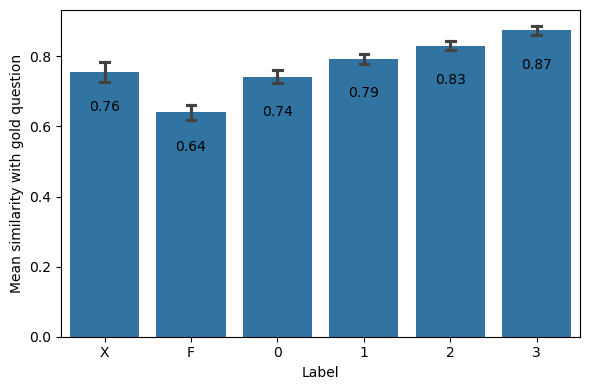

In [15]:
plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=result,
    x="label",
    y="similarity_with_gold",
    order=["X", "F", "0", "1", "2", "3"],
    errorbar=("ci", 95),
    capsize=0.1,
)

ax.bar_label(
    ax.containers[0],
    fmt="%.2f",
    padding=-30,

)

plt.xlabel("Label")
plt.ylabel("Mean similarity with gold question")
plt.tight_layout()
plt.show()

In [16]:
result[result['label'] == 'X'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3, random_state=42)

,extracted_question,gold_question,similarity_with_gold,label
115,Isso pode prejudicar o sono dele à noite?,Posso dormir de barriga pra cima?,0.690001,X
304,"Nesse caso, a chupeta não seria uma aliada?","Se eu não tiver força pra empurrar o bebe, será que alguém empurra minha barriga?",0.679717,X
2,O que o bebê tem na barriga?,O formato da barriga indica o sexo do bebê?,0.859242,X


In [17]:
result[result['label'] == 'F'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3, random_state=42)

,extracted_question,gold_question,similarity_with_gold,label
14,"Como saber se a bomba elétrica de tirar leite está carregando ou já está totalmente carregada, sem o manual?",O que posso fazer para aumentar o leite?,0.688596,F
224,"Se eu precisar pagar o INSS, como faço o pagamento pelo aplicativo Meu INSS?",O que devo fazer se eu me sentir mal antes da data da próxima consulta?,0.531026,F
65,"O atraso menstrual de 21 dias pode estar relacionado à endometriose, ao endometrioma ou ao mioma?",A gravidez pode durar mais do que 9 meses?,0.620189,F


In [18]:
result[result['label'] == '0'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3, random_state=42)

,extracted_question,gold_question,similarity_with_gold,label
142,A alimentação da mãe pode causar cólicas no bebê no mesmo dia em que o alimento é ingerido?,Ter cólica na barriga pode ser um problema?,0.762190,0
10,É normal voltar a sair uma secreção transparente meio amarelada com 42 semanas e 2 dias de gravidez?,"É normal sair um líquido amarelado pelo seio, durante a gravidez?",0.858953,0
264,O que é o tampão no contexto da gravidez e do parto?,O que é o Plano de Parto?,0.758192,0


In [19]:
result[result['label'] == '1'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3, random_state=42)

,extracted_question,gold_question,similarity_with_gold,label
131,"É normal sentir muito movimento e pontadas rápidas na barriga, como se estivesse grávida de três meses?",Estou sentindo contrações antes do nono mês. É normal?,0.849229,1
317,Você já recebeu o resultado positivo do teste de gravidez?,Como ter certeza que estou grávida?,0.814365,1
296,E o teste do pezinho do bebê?,O que é Teste do Olhinho?,0.768123,1


In [20]:
result[result['label'] == '2'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3, random_state=42)

,extracted_question,gold_question,similarity_with_gold,label
19,O bebê dentro da barriga sente desconforto?,O movimento do bebê dentro do útero é porque ele está incomodado?,0.885308,2
186,"A implantação do embrião pode causar uma dor sutil, como uma facada do lado direito do útero?",Ter um pouco de dor na barriga é normal?,0.759931,2
63,Como evitar dores nos seios durante a gravidez?,"Como preparar o seio para a amamentação, durante a gravidez?",0.884159,2


In [21]:
result[result['label'] == '3'][['extracted_question', 'gold_question', 'similarity_with_gold', 'label']].sample(3)

,extracted_question,gold_question,similarity_with_gold,label
285,Qual tinta de cabelo pode ser usada durante a gravidez?,Posso pintar o cabelo durante a gravidez?,0.940339,3
370,É verdade que é preciso fazer um corte naquela região para o bebê sair no parto?,Preciso de corte na vagina para o meu bebe nascer?,0.895682,3
153,O homem pode acompanhar e ajudar durante o parto?,Posso convidar alguém para ficar sempre do meu lado no parto?,0.841564,3
